# repgen3d pipeline v1 - full 3D twin-aware workflow
Load an EBSD `.ctf` file as the **target grain structure**, process it through the complete twin-aware pipeline: crop -> clean -> MDF -> CSL segregation -> parent/twin identification -> merged EBSD -> **3D MC generation** -> **3D representativeness ranking via 2D slices** -> twin host allocation.

## Part A - EBSD pre-processing

### S1  Configuration

In [1]:
# -- EBSD input ----------------------------------------------------------------
CTF_FILE        = r'C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2.ctf'
MIN_GRAIN_SIZE  = 10    # pixels - grains smaller than this are flagged -2
MISORI_TOL      = 8     # degrees - grain-boundary misorientation threshold
CROP_REGION     = [1, 1, 99, 99]   # [xstart%, ystart%, xend%, yend%]

# -- Simulated grain structure -------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
TSLICE_INDEX    = 10    # index into pxt.m[] used to pick the best-matching tslice

### S2  Import statements

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

import cc3d

from upxo.repgen.repgen2dmcgs import repgen2d
from upxo.interfaces.defdap.ebsd_reader import EBSDReader
from upxo.ggrowth.mcgs import mcgs
from upxo.pxtal.geometrification import GrainManifold2D
from upxo.gsdataops.gid_ops import find_neighs2d
from shapely.geometry import MultiPolygon

import upxo.viz.ebsdviz as ebsdviz
import upxo.gsdataops.grid_ops as gridOps
from upxo.viz import gsviz

### S3  EBSD reader - write subsampled CTF, load, crop

In [3]:
import os
from upxo.interfaces.defdap.ebsd_reader import EBSDReader, write_subsampled_ctf

# -- paths -------------------------------------------------------------------
CTF_SRC = CTF_FILE
CTF_DST = CTF_SRC.replace('.ctf', '_s3.ctf')
STRIDE  = 2

out_path = write_subsampled_ctf(CTF_SRC, CTF_DST, stride_x=STRIDE, stride_y=STRIDE)
print(f'Written          : {out_path}')
print(f'Size original    : {os.path.getsize(CTF_SRC) / 1e6:.1f} MB')
print(f'Size sub-sampled : {os.path.getsize(CTF_DST) / 1e6:.1f} MB')

Written          : C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2_s3.ctf
Size original    : 43.1 MB
Size sub-sampled : 10.8 MB


### S4  Initiate repgen2d

In [4]:
CTF_FILE = CTF_DST
rdr = EBSDReader.from_file(CTF_FILE, min_grain_size=MIN_GRAIN_SIZE, misori_tol=MISORI_TOL)
rdr = rdr.crop(CROP_REGION, inplace=False)

Loaded EBSD data (dimensions: 513 x 363 pixels, step size: 0.8 um)
Finished building quaternion array (0:00:00) 
Finished finding grain boundaries (0:00:02) 
Finished finding grains (0:00:01) 
[crop] region=[1, 1, 99, 99]%  →  rows 4:359, cols 5:508  |  original 363×513  →  cropped 355×503


### S5  Compute MDF

[rechar_lfi] Map 355×503  |  unknown pixels: 3619 (2.03%)  |  connectivity=4
[rechar_lfi] Step 1/5 — labelling unknown connected components …
[rechar_lfi]           1569 connected components found.
[rechar_lfi] Step 2/5 — computing grain adjacency …
[rechar_lfi] Step 3/5 — assigning CC pixels to grains …


  assigning CCs:   0%|          | 0/1569 [00:00<?, ?CC/s]

[rechar_lfi]           1569/1569 CCs assigned (3619 pixels filled).
[rechar_lfi] Step 4/5 — computing grain-average orientations (vectorized) …
[rechar_lfi]           381 unique grains to average over.
[rechar_lfi]           averaging Euler channels (3) …
[rechar_lfi]           averaging quaternion channels (4) …
[rechar_lfi]           orientation averages ready.
[rechar_lfi] Step 5/5 — writing orientations for 3619 unknown pixels (vectorised, no loop) …
[rechar_lfi]           3619 pixels written (0 isolated islands left unfilled).
[rechar_lfi] Done.
clean_and_rechar_from_rdr() completed in 6.4 s
Non-positive pixels remaining : 111
Grains after cleaning         : 1058
Neighbour entries             : 1058
prop_ebsd grain count         : 1058
Property                      mean         std         min         max   count
---------------------------------------------------------------------------
area                       107.949     212.303       6.400    2436.480    1058
perimeter      

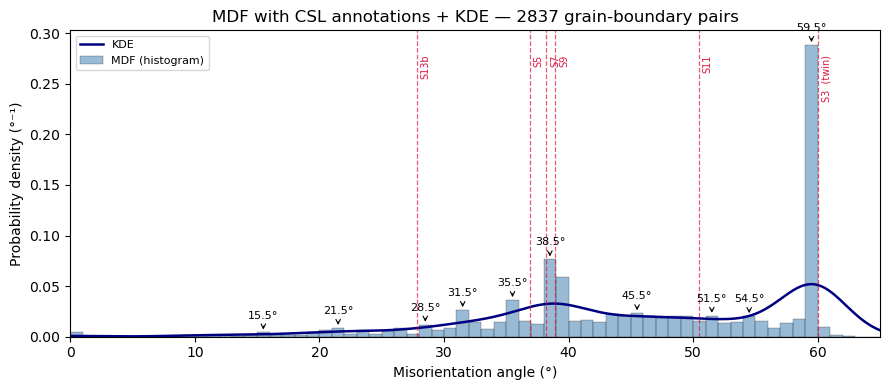

In [5]:
rg = repgen2d.from_tgs(tgs=None, tgstype='ebsd2d', ebsd_file=CTF_FILE)
rg.set_ebsd_step(rdr.step_size)
rg.clean_and_rechar_from_rdr(rdr, connectivity=4, min_grain_size=MIN_GRAIN_SIZE)
rg.compute_ebsd_stats()

mdf, peaks = rg.compute_mdf_ebsd()

### S6  Select MDF peaks of interest

In [6]:
selected_peaks = rg.select_mdf_peaks(peaks)

Select which MDF peaks to retain for downstream analysis:


### S7  Plot MDF with selected peaks

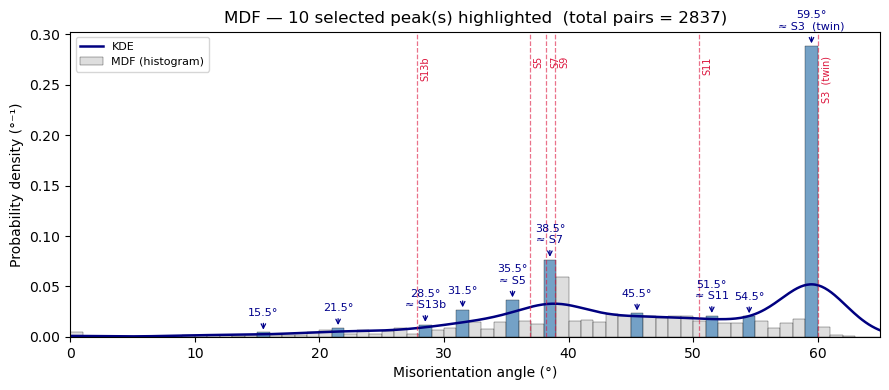

Selected peak angles : [15.5, 21.5, 28.5, 31.5, 35.5, 38.5, 45.5, 51.5, 54.5, 59.5]


In [7]:
rg.plot_mdf_selected(mdf, peaks, selected_peaks)

### S8  Segregate CSL pairs and visualise

CSL type            ref °   pairs   grains
──────────────────────────────────────────
S13b                27.80      84      145
S5                  36.87     343      453
S7                  38.21     466      597
S11                 50.48     211      317
S3  (twin)          60.00     898      948


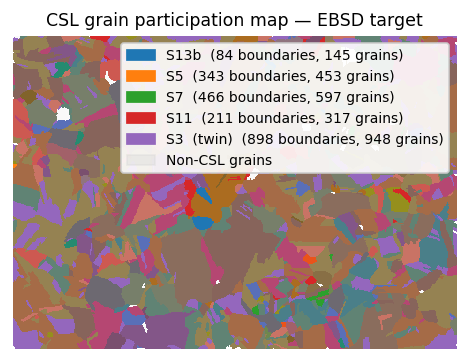

In [8]:
csl_grains = rg.segregate_csl_pairs(mdf, selected_peaks, peaks['csl'], peaks['csl_tol'])
rg.see_csl_grain_map(csl_grains, figsize=(6, 3), dpi=125)

### S9  CSL volume fractions

CSL type            ref °   grains    pixels   VF (indexed)   VF (total)
──────────────────────────────────────────────────────────────────────
S13b                27.80      145     50119        28.09%      28.07%
S5                  36.87      453    103827        58.18%      58.15%
S7                  38.21      597    132019        73.98%      73.93%
S11                 50.48      317     94818        53.13%      53.10%
S3  (twin)          60.00      948    165325        92.64%      92.59%


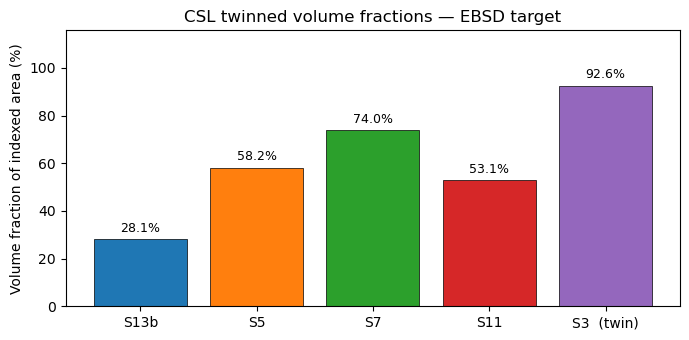

In [9]:
cslvf = rg.compute_csl_volume_fractions(csl_grains)

### S10  Identify parent grains

CSL type            ref °   pairs   pure parents   pure twins   intermediates
───────────────────────────────────────────────────────────────────────────
S13b                27.80      84             67           74               4
S5                  36.87     343            178          214              61
S7                  38.21     466            212          300              85
S11                 50.48     211            132          158              27
S3  (twin)          60.00     898            243          497             208


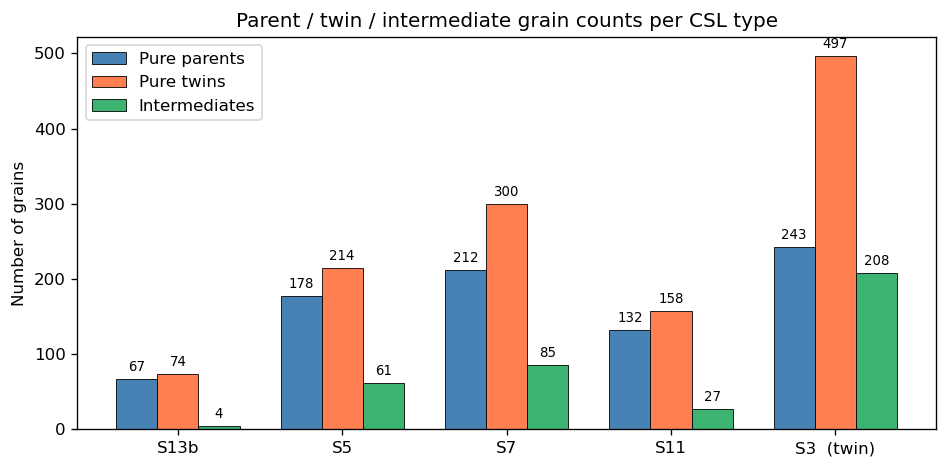

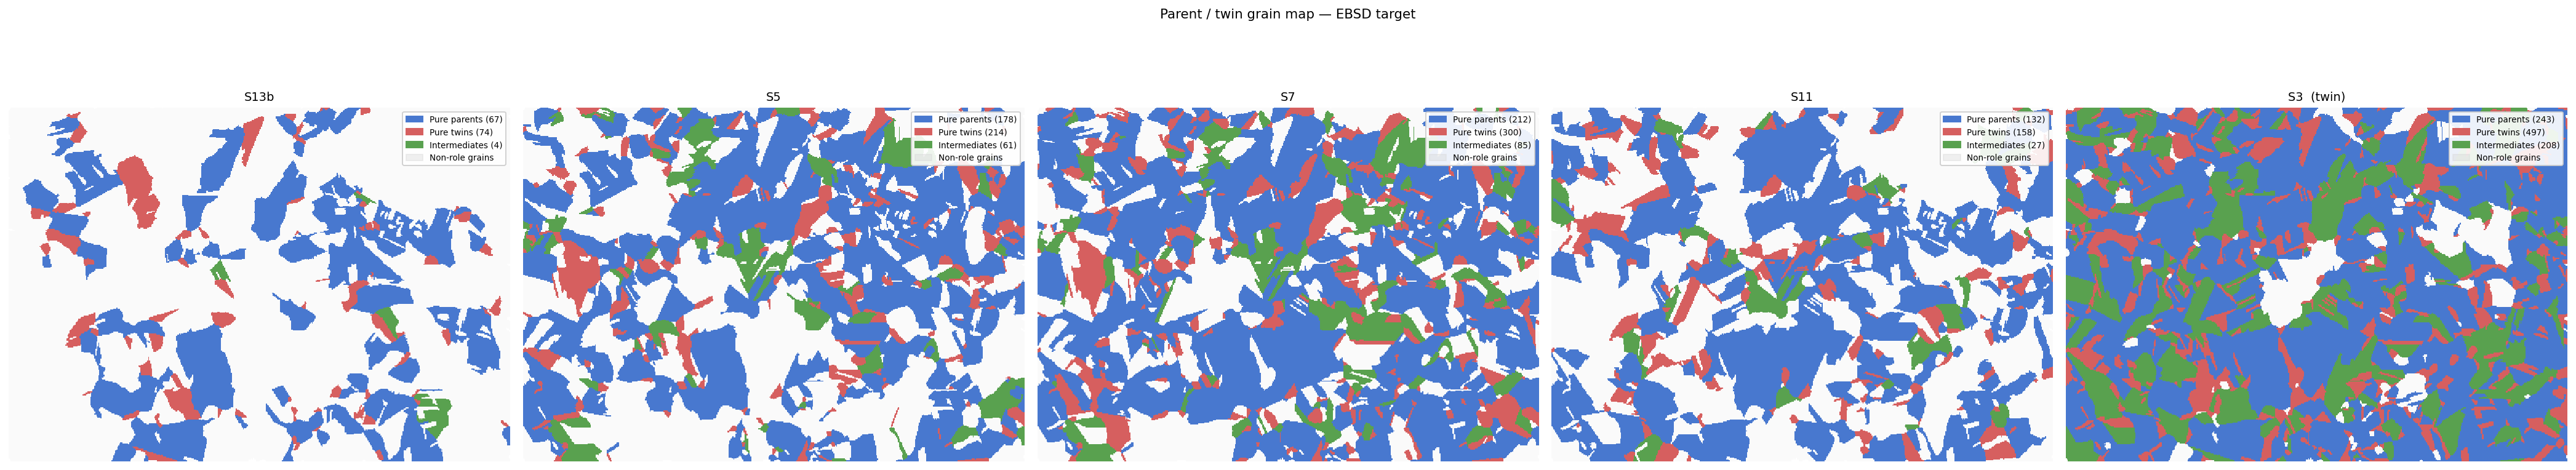

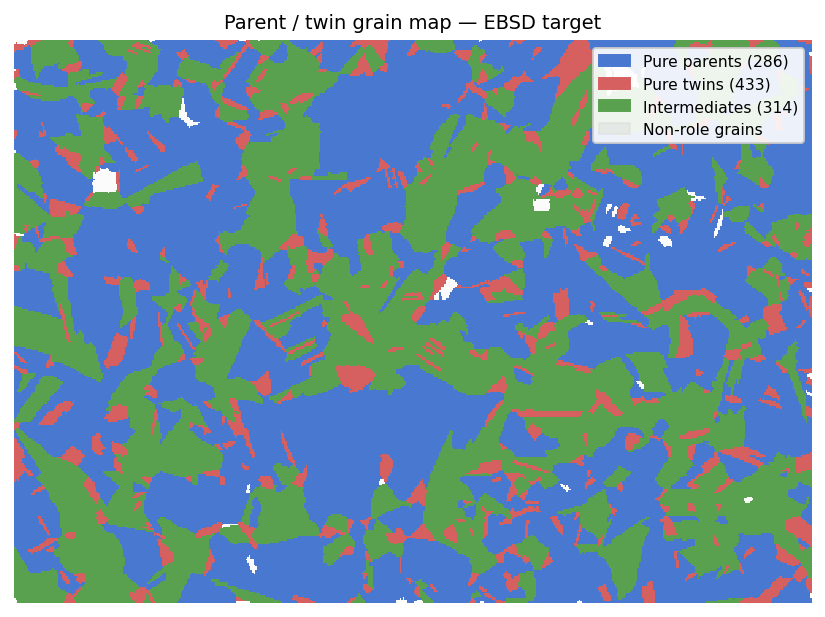

In [10]:
parent_info = rg.identify_parent_grains(csl_grains, plot_parent_twin_maps=True, plot_combined_parent_twin_map=True)

### S11  EBSD twin area fractions - compute

In [11]:
tvf = rg.compute_ebsd_tvf(parent_info)
print(f"CSL label                  : {tvf['csl_label']}")
print(f"Overall twin area fraction : {tvf['overall_twin_frac']:.4f}")
print(f"  Pure parents             : {tvf['pure_parent_frac']:.4f}")
print(f"  Primary twins (1st gen)  : {tvf['primary_twin_frac']:.4f}")
print(f"  Secondary twins (2nd gen): {tvf['secondary_twin_frac']:.4f}")
print(f"  Intermediate twins       : {tvf['intermediate_frac']:.4f}")
print(f"  No-role grains           : {tvf['non_role_frac']:.4f}")
print(f"  {'-' * 41}")
print(f"  Sum check                : {tvf['overall_twin_frac'] + tvf['pure_parent_frac'] + tvf['non_role_frac']:.4f}")

compute_ebsd_tvf: auto-selected CSL label  → "S13b"
  Available labels: ['S13b', 'S5', 'S7', 'S11', 'S3  (twin)']
CSL label                  : S13b
Overall twin area fraction : 0.0574
  Pure parents             : 0.2234
  Primary twins (1st gen)  : 0.0478
  Secondary twins (2nd gen): 0.0014
  Intermediate twins       : 0.0082
  No-role grains           : 0.7191
  -----------------------------------------
  Sum check                : 1.0000


### S12  EBSD twin area fractions - plot

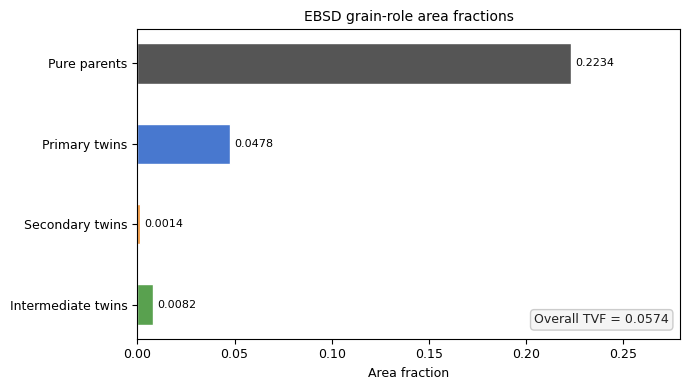

In [12]:
rg.plot_ebsd_tvf(tvf)

### S13  Build merged EBSD labelled feature image (LFI)

[merge_info]  merged grains: 157  |  with twins: 132  |  twin-hosting fraction: 0.8408


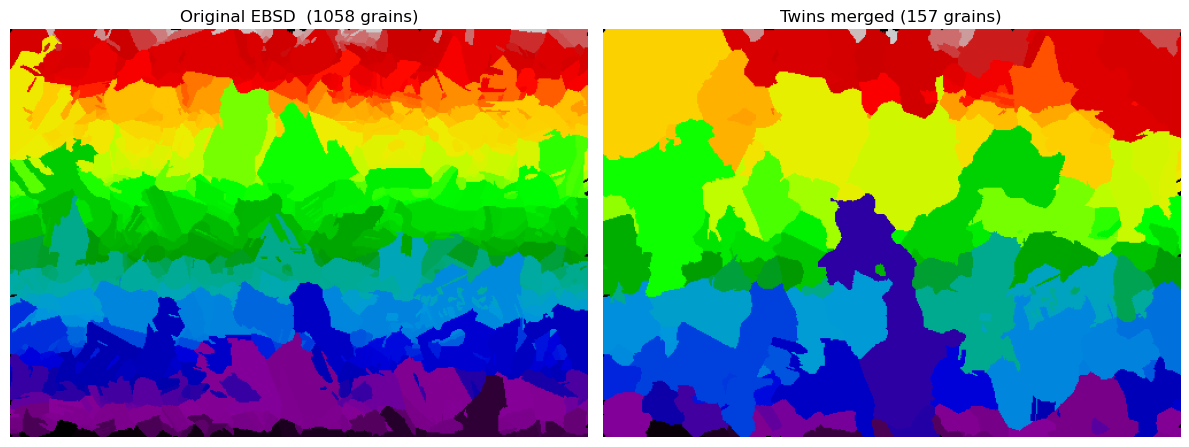

In [13]:
rg.build_merged_ebsd_lfi(parent_info)

### S14  Merge provenance

In [14]:
print(f"Merged grains total    : {rg.merge_info['n_merged_total']}")
print(f"Grains with twins      : {rg.merge_info['n_hosting_grains']}")
print(f"Twin-hosting fraction  : {rg.merge_info['twin_hosting_fraction']:.4f}")

Merged grains total    : 157
Grains with twins      : 132
Twin-hosting fraction  : 0.8408


## Part B - Grain role property analysis (twin GS)

### S15  Select GS properties for twin analysis

In [15]:
twinPropSelection = rg.selectProps_twinGS()

### S16  Read selected properties and view distributions

Properties : ['area']
Groups     : ['pure_parents', 'pure_twins', 'intermediates', 'non_role']


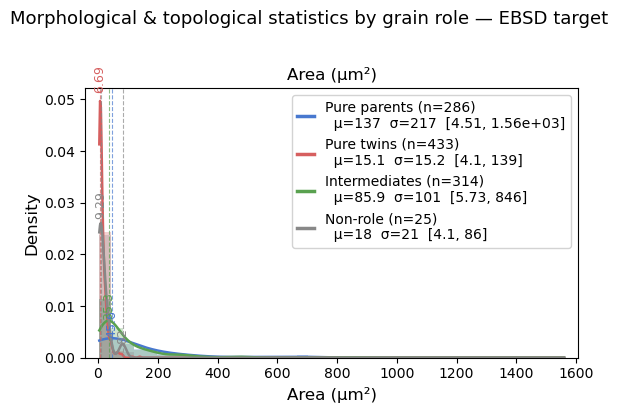

In [16]:
twinProps = rg.readProps_twinGS(twinPropSelection)
rg.see_grain_role_property_stats(parent_info, twinProps)

In [17]:
# Diagnostic: Check available attributes on rg object
print("Available attributes on rg object:")
print("=" * 60)
rg_attrs = [attr for attr in dir(rg) if not attr.startswith('_')]
print(f"Total attributes: {len(rg_attrs)}")
print()

# Look for attributes related to LFI or merged image
lfi_attrs = [attr for attr in rg_attrs if 'lfi' in attr.lower() or 'image' in attr.lower() or 'merge' in attr.lower()]
print(f"Attributes containing 'lfi', 'image', or 'merge':")
for attr in lfi_attrs:
    try:
        val = getattr(rg, attr)
        if hasattr(val, 'shape'):
            print(f"  {attr}: {type(val).__name__} shape={val.shape}")
        else:
            print(f"  {attr}: {type(val).__name__}")
    except:
        print(f"  {attr}: (error accessing)")


Available attributes on rg object:
Total attributes: 96

Attributes containing 'lfi', 'image', or 'merge':
  build_merged_ebsd_lfi: method
  lfi_ebsd: ndarray shape=(355, 503)
  lfi_ebsd_merged: ndarray shape=(355, 503)
  merge_info: dict
  prop_ebsd_merged: dict
  prop_ebsd_merged_df: DataFrame shape=(157, 10)


## Part C - 3D MC grain structure generation

### S17  Configuration & setup

In [18]:
# -- 3D MC Configuration -------------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
MC_TIME_START    = 2      # Start time slice index
MC_TIME_END      = -1     # End time slice index (-1 = all)
MC_TIME_STEP     = 2      # Sample every N time steps
CHARACTERIZE     = True   # Compute grain properties
MIN_GRAIN_SIZE   = 4      # Minimum grain voxel count

print('Configuration loaded.')

Configuration loaded.


### S18  Instantiate MCGS and load 3D MC dashboard

In [19]:
from upxo.ggrowth.mcgs import mcgs

pxt = mcgs(study='independent', input_dashboard=INPUT_DASHBOARD)

print('MCGS Configuration loaded:')
print(pxt)
print('\nGrid parameters:')
print(pxt.uigrid)
print('\nSimulation parameters:')
print(pxt.uisim)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls
Algo_hops details
(('300b', 100),)
[False]
MCGS Configuration loaded:
x:(0.0,50.0,1.0), y:(0.0,50.0,1.0), z:(0.0,50.0,1.0).

Grid parameters:
Attribues of gridding definitions: 
     TYPE: square
     DIMENSIONALITY: 3
     X: (0.0, 50.0, 1.0)
     Y: (0.0, 50.0, 1.0)
     Z: (0.0, 50.0, 1.0)
     PIXEL SIZE: 1.0
     TRANSFORMATION: none

Simulation parameters:
Attributes of Simulation parameters:
     MCSTEPS: 100
     S: 10 - will be deprecated.
     STATE SAMPLING SCHEME: rejection
     CONSIDER BOLTZMANN PROBABILITY: False
     S BOLTZAMNN PROBABILITY: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
     MAXIMUM BOLTZMANN TEMPERATURE FACTOR: 0.0
     BOUNDARY CONDITION TYPE: wrapped
     NON LOCALITY: 1
     KINETICITY: static



### S19  Run 3D Monte Carlo simulation

In [20]:
print('Starting 3D MC grain structure simulation...')
pxt.simulate(verbose=False)

print(f'\nSimulation complete!')
print(f'Number of temporal slices: {len(pxt.m)}')
print(f'Available time slice indices: {pxt.m[:10]}... (showing first 10)')

Starting 3D MC grain structure simulation...

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 50.0, 1.0
     No. of states: 10
     Dimensionality: 3
Using ALG-300b
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS temporal slice 18 stored
GS temporal slice 19 stored
GS temporal slice 20 stored
GS temporal slice 21 stored
GS temporal slice 22 stored
GS temporal 

### S20  Select temporal slices for analysis

In [21]:
tslice_for_detailed_analysis = pxt.m[-1]
tslices_for_repr_analysis = pxt.m[MC_TIME_START::MC_TIME_STEP]

print(f'Detailed analysis time slice: {tslice_for_detailed_analysis}')
print(f'Representativeness analysis time slices: {tslices_for_repr_analysis[:5]}... (showing first 5)')
print(f'Total time slices for representativeness analysis: {len(tslices_for_repr_analysis)}')

Detailed analysis time slice: 99
Representativeness analysis time slices: [np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]... (showing first 5)
Total time slices for representativeness analysis: 49


### S21  Characterize 3D grain morphology

In [22]:
gstslice = pxt.gs[tslice_for_detailed_analysis]

gstslice.char_morphology_of_grains(
    label_str_order=1,
    find_grain_voxel_locs=True,
    find_spatial_bounds_of_grains=True,
    force_compute=True
)

gstslice.set_mprops(
    volnv=True,
    eqdia=True,
    eqdia_base_size_spec='volnv',
    arbbox=False,
    arellfit=False,
    solidity=False,
    sanv=False
)

print(f'Grain characterization complete!')
print(f'Number of grains: {gstslice.n}')
print(f'Available properties: {list(gstslice.mprop.keys())}')

---------------------------------------- 
Finding grains.
No. of grains detected = 102
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: {sf_name} to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['{sf_name}']

Finding voxel locations of grains in lgi.

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------
---------------------------------------- 
Setting grain eq.sph.dia. values (metric: 'eqdia').
Grain characterization complete!
Number of grains: 102
A

### S22  3D grain structure summary statistics

In [23]:
n_grains = gstslice.n
print(f'3D MC Grain Structure Summary (Time Slice {tslice_for_detailed_analysis})')
print(f'{'-' * 60}')
print(f'Domain size: 60 x 60 x 60 voxels (60 x 60 x 60 um)')
print(f'Number of grains: {n_grains}')
print(f'Voxel size: {pxt.vox_size} um')

# Volume statistics - extract values from dict
volnv_dict = gstslice.mprop['volnv']
volnv = np.array(list(volnv_dict.values()))
print(f'\nVolume statistics (voxel-based):')
print(f'  Mean: {np.mean(volnv):.1f} voxels')
print(f'  Median: {np.median(volnv):.1f} voxels')
print(f'  Std Dev: {np.std(volnv):.1f} voxels')
print(f'  Min: {np.min(volnv):.1f} voxels')
print(f'  Max: {np.max(volnv):.1f} voxels')

# Equivalent diameter statistics - extract values from dict
eqdia_dict = gstslice.mprop['eqdia']
eqdia = np.array(list(eqdia_dict['values']))
print(f'\nEquivalent diameter statistics:')
print(f'  Mean: {np.mean(eqdia):.2f} um')
print(f'  Median: {np.median(eqdia):.2f} um')
print(f'  Std Dev: {np.std(eqdia):.2f} um')
print(f'  Min: {np.min(eqdia):.2f} um')
print(f'  Max: {np.max(eqdia):.2f} um')

print(f'\n{'-' * 60}')
print(f'Ready for Part D: 3D Representativeness Assessment')

3D MC Grain Structure Summary (Time Slice 99)
------------------------------------------------------------
Domain size: 60 x 60 x 60 voxels (60 x 60 x 60 um)
Number of grains: 102
Voxel size: 1.0 um

Volume statistics (voxel-based):
  Mean: 1225.5 voxels
  Median: 392.0 voxels
  Std Dev: 2635.3 voxels
  Min: 1.0 voxels
  Max: 21328.0 voxels

Equivalent diameter statistics:
  Mean: 9.91 um
  Median: 9.08 um
  Std Dev: 6.15 um
  Min: 1.24 um
  Max: 34.41 um

------------------------------------------------------------
Ready for Part D: 3D Representativeness Assessment


## Part D - 3D representativeness assessment (2D slice validation)

### S23  Configuration for 3D representativeness assessment

In [24]:
# -- 3D Representativeness Configuration -----------------------------------
N_SLICES_X = 10        # Number of slices perpendicular to X axis
N_SLICES_Y = 10        # Number of slices perpendicular to Y axis
N_SLICES_Z = 10        # Number of slices perpendicular to Z axis

TEST_ALONG_X = True    # Enable X-axis validation
TEST_ALONG_Y = True    # Enable Y-axis validation
TEST_ALONG_Z = True    # Enable Z-axis validation

P_PERCENTAGE = 60.0    # Acceptance threshold: % of slices that must pass per axis

print('Configuration loaded:')
print(f'  X slices: {N_SLICES_X}, test: {TEST_ALONG_X}')
print(f'  Y slices: {N_SLICES_Y}, test: {TEST_ALONG_Y}')
print(f'  Z slices: {N_SLICES_Z}, test: {TEST_ALONG_Z}')
print(f'  Acceptance threshold: {P_PERCENTAGE}%')

Configuration loaded:
  X slices: 10, test: True
  Y slices: 10, test: True
  Z slices: 10, test: True
  Acceptance threshold: 60.0%


### S24  Helper functions for 2D slice extraction

In [25]:
from upxo.gsdataops.grid_ops import section_from_3d
from upxo.charops.mchar import get_grain_size_distribution_from_slice

# section_from_3d(lgi_3d, axis, location) extracts a 2D slice
# get_grain_size_distribution_from_slice(lgi_2d) returns grain pixel-count array
MDF_WASSERSTEIN_THRESHOLD_DEG = 5.0
print('Slice utilities imported. MDF_WASSERSTEIN_THRESHOLD_DEG =', MDF_WASSERSTEIN_THRESHOLD_DEG)

Slice utilities imported. MDF_WASSERSTEIN_THRESHOLD_DEG = 5.0


### S25  Extract 2D slices and compute representativeness metrics

In [26]:
from scipy.stats import wasserstein_distance, ks_2samp, anderson_ksamp

# Get 3D LGI from selected time slice
lgi_3d = gstslice.lgi

# Get EBSD reference grain size distribution (area in pixels)
ebsd_merged_lfi = rg.lfi_ebsd_merged
ebsd_grain_ids = np.unique(ebsd_merged_lfi)
ebsd_grain_ids = ebsd_grain_ids[ebsd_grain_ids > 0]
ebsd_areas = np.array([np.sum(ebsd_merged_lfi == gid) for gid in ebsd_grain_ids])

# Dictionary to store slice comparison results
slice_results = {}
axes_config = [
    (0, N_SLICES_X, 'X', TEST_ALONG_X),
    (1, N_SLICES_Y, 'Y', TEST_ALONG_Y),
    (2, N_SLICES_Z, 'Z', TEST_ALONG_Z),
]

for axis, n_slices, axis_name, test_enabled in axes_config:
    if not test_enabled:
        continue
    
    axis_results = []
    domain_size = lgi_3d.shape[axis]
    slice_indices = np.linspace(0, domain_size - 1, n_slices, dtype=int)
    
    print(f'\nProcessing {axis_name}-normal slices (n={n_slices})...')
    
    for slice_num, slice_idx in enumerate(slice_indices):
        # Extract 2D slice
        lgi_2d = section_from_3d(lgi_3d, axis=axis, location=slice_idx)
        mc_areas = get_grain_size_distribution_from_slice(lgi_2d)
        
        # Normalize by mean for comparison
        ebsd_norm = ebsd_areas / np.mean(ebsd_areas)
        mc_norm = mc_areas / np.mean(mc_areas) if len(mc_areas) > 0 else np.array([])
        
        # Compute metrics
        if len(mc_areas) > 0 and len(ebsd_areas) > 0:
            wasserstein = wasserstein_distance(ebsd_norm, mc_norm)
            ks_stat, ks_pval = ks_2samp(ebsd_norm, mc_norm)
            
            # Simple pass/fail: Wasserstein < 0.5 is considered representative
            passes = wasserstein < 0.5
        else:
            wasserstein = np.inf
            ks_stat = np.inf
            passes = False
        
        axis_results.append({
            'slice_idx': slice_idx,
            'wasserstein': wasserstein,
            'ks_stat': ks_stat,
            'passes': passes,
            'n_grains': len(mc_areas)
        })
    
    slice_results[axis_name] = axis_results
    n_pass = sum(1 for r in axis_results if r['passes'])
    pct_pass = 100.0 * n_pass / len(axis_results) if len(axis_results) > 0 else 0
    print(f'  Result: {n_pass}/{len(axis_results)} slices pass ({pct_pass:.1f}%)')

print('\nSlice analysis complete.')


Processing X-normal slices (n=10)...
  Result: 10/10 slices pass (100.0%)

Processing Y-normal slices (n=10)...
  Result: 9/10 slices pass (90.0%)

Processing Z-normal slices (n=10)...
  Result: 10/10 slices pass (100.0%)

Slice analysis complete.


### S26  Aggregate representativeness scores per axis

In [27]:
# Compute per-axis acceptance
axis_acceptance = {}

print('\nPer-Axis Representativeness Summary')
print('=' * 60)

for axis_name, results in slice_results.items():
    n_pass = sum(1 for r in results if r['passes'])
    n_total = len(results)
    pct_pass = 100.0 * n_pass / n_total if n_total > 0 else 0
    
    accepted = pct_pass >= P_PERCENTAGE
    axis_acceptance[axis_name] = {
        'n_pass': n_pass,
        'n_total': n_total,
        'pct_pass': pct_pass,
        'accepted': accepted
    }
    
    status = 'ACCEPTED' if accepted else 'REJECTED'
    print(f'{axis_name}-axis: {n_pass}/{n_total} slices pass ({pct_pass:.1f}%) [{status}]')

# Overall acceptance
overall_accepted = all(info['accepted'] for info in axis_acceptance.values())

print('\n' + '=' * 60)
if overall_accepted:
    print('OVERALL 3D ACCEPTANCE: YES')
    print('This 3D MC structure is representative of the EBSD reference.')
else:
    rejected_axes = [ax for ax, info in axis_acceptance.items() if not info['accepted']]
    print(f'OVERALL 3D ACCEPTANCE: NO')
    print(f'Rejected axes: {rejected_axes}')
print('=' * 60)


Per-Axis Representativeness Summary
X-axis: 10/10 slices pass (100.0%) [ACCEPTED]
Y-axis: 9/10 slices pass (90.0%) [ACCEPTED]
Z-axis: 10/10 slices pass (100.0%) [ACCEPTED]

OVERALL 3D ACCEPTANCE: YES
This 3D MC structure is representative of the EBSD reference.


### S27  Visualize representativeness results


Representativeness Summary Table:
Axis Pass/Total Percent Threshold Accept
   X      10/10  100.0%     60.0%    YES
   Y       9/10   90.0%     60.0%    YES
   Z      10/10  100.0%     60.0%    YES


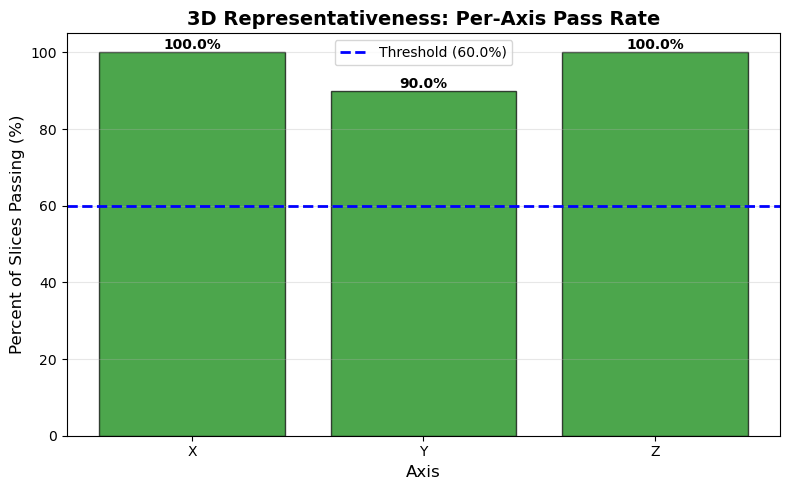


Visualization complete.


In [28]:
# Create summary table
import pandas as pd

summary_data = []
for axis_name, info in axis_acceptance.items():
    summary_data.append({
        'Axis': axis_name,
        'Pass/Total': f"{info['n_pass']}/{info['n_total']}",
        'Percent': f"{info['pct_pass']:.1f}%",
        'Threshold': f"{P_PERCENTAGE:.1f}%",
        'Accept': 'YES' if info['accepted'] else 'NO'
    })

df = pd.DataFrame(summary_data)
print('\nRepresentativeness Summary Table:')
print(df.to_string(index=False))

# Plot pass rates per axis
fig, ax = plt.subplots(figsize=(8, 5))
axes_names = list(axis_acceptance.keys())
pct_passes = [axis_acceptance[ax]['pct_pass'] for ax in axes_names]
colors = ['green' if axis_acceptance[ax]['accepted'] else 'red' for ax in axes_names]

bars = ax.bar(axes_names, pct_passes, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=P_PERCENTAGE, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({P_PERCENTAGE}%)')
ax.set_ylabel('Percent of Slices Passing (%)', fontsize=12)
ax.set_xlabel('Axis', fontsize=12)
ax.set_title('3D Representativeness: Per-Axis Pass Rate', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, pct in zip(bars, pct_passes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nVisualization complete.')

### S28  Status and next steps

In [29]:
print('\n3D Representativeness Assessment Complete')
print('=' * 60)
print(f'\nMC Time Slice: {tslice_for_detailed_analysis}')
print(f'Overall Acceptance: {"PASS" if overall_accepted else "FAIL"}')
print(f'\nDomain: 60 x 60 x 60 voxels')
print(f'Number of grains: {gstslice.n}')
print(f'\nP-percentage threshold: {P_PERCENTAGE}%')
print(f'Axes tested: {list(slice_results.keys())}')

if overall_accepted:
    print(f'\nNext: Proceed to Part E - Twin host allocation')
else:
    print(f'\nRecommendation: Select different MC time slice for better representativeness')

print('=' * 60)


3D Representativeness Assessment Complete

MC Time Slice: 99
Overall Acceptance: PASS

Domain: 60 x 60 x 60 voxels
Number of grains: 102

P-percentage threshold: 60.0%
Axes tested: ['X', 'Y', 'Z']

Next: Proceed to Part E - Twin host allocation


## Part E - Twin host allocation

### S29  Extract target twin hosting fraction from EBSD

In [30]:
# From Part A (tvf dictionary), get target hosting fraction
target_hosting_fraction = rg.merge_info['twin_hosting_fraction']

# Total grains in 3D MC structure
n_grains_3d = gstslice.n

# Target number of host grains
n_hosts_target = int(np.round(target_hosting_fraction * n_grains_3d))

print(f'Target twin hosting fraction: {target_hosting_fraction:.4f}')
print(f'Total 3D grains: {n_grains_3d}')
print(f'Target host grains: {n_hosts_target}')

Target twin hosting fraction: 0.8408
Total 3D grains: 102
Target host grains: 86


### S30  Allocate twin hosts by grain volume

In [31]:
# Get grain volumes (already computed in Part C)
volnv_dict = gstslice.mprop['volnv']  # Dict keyed by grain ID

# Convert to list of (grain_id, volume) tuples
grain_volumes = [(gid, vol) for gid, vol in volnv_dict.items()]

# Sort by volume (descending)
grain_volumes_sorted = sorted(grain_volumes, key=lambda x: x[1], reverse=True)

# Select largest grains as hosts
host_grain_ids = set()
host_volume_total = 0
total_volume = sum(v for _, v in grain_volumes)

for grain_id, volume in grain_volumes_sorted:
    host_grain_ids.add(grain_id)
    host_volume_total += volume
    
    # Check if we've reached target fraction
    current_fraction = host_volume_total / total_volume
    if len(host_grain_ids) >= n_hosts_target or current_fraction >= target_hosting_fraction:
        break

# Non-host grains
non_host_grain_ids = set(volnv_dict.keys()) - host_grain_ids

# Compute actual achieved fraction
actual_fraction = host_volume_total / total_volume
actual_n_hosts = len(host_grain_ids)

print(f'Allocated {actual_n_hosts} host grains')
print(f'Achieved hosting fraction: {actual_fraction:.4f}')
print(f'Non-host grains: {len(non_host_grain_ids)}')

Allocated 31 host grains
Achieved hosting fraction: 0.8485
Non-host grains: 71


### S31  Visualize host grain distribution and statistics

In [32]:
# Volume statistics for hosts vs non-hosts
host_volumes = [vol for gid, vol in grain_volumes if gid in host_grain_ids]
nonhost_volumes = [vol for gid, vol in grain_volumes if gid in non_host_grain_ids]

print('Host Grain Statistics:')
print(f'  Count: {len(host_volumes)}')
print(f'  Mean volume: {np.mean(host_volumes):.1f} voxels')
print(f'  Median volume: {np.median(host_volumes):.1f} voxels')
print(f'  Min volume: {np.min(host_volumes):.1f} voxels')
print(f'  Max volume: {np.max(host_volumes):.1f} voxels')

print('\nNon-Host Grain Statistics:')
print(f'  Count: {len(nonhost_volumes)}')
print(f'  Mean volume: {np.mean(nonhost_volumes):.1f} voxels')
print(f'  Median volume: {np.median(nonhost_volumes):.1f} voxels')
print(f'  Min volume: {np.min(nonhost_volumes):.1f} voxels')
print(f'  Max volume: {np.max(nonhost_volumes):.1f} voxels')

# Compare to EBSD - use correct CSL label from Part A
csl_label = tvf['csl_label']
ebsd_pure_parents = parent_info[csl_label]['pure_parents']

print('\nComparison to EBSD Pure Parents:')
print(f'  CSL label: {csl_label}')
print(f'  EBSD pure parent count: {len(ebsd_pure_parents)}')
print(f'  MC host count: {actual_n_hosts}')
print(f'  Ratio: {actual_n_hosts / len(ebsd_pure_parents):.2f}x')

print(f'\nHost grain allocation complete.')

Host Grain Statistics:
  Count: 31
  Mean volume: 3421.3 voxels
  Median volume: 2254.0 voxels
  Min volume: 1082.0 voxels
  Max volume: 21328.0 voxels

Non-Host Grain Statistics:
  Count: 71
  Mean volume: 266.8 voxels
  Median volume: 146.0 voxels
  Min volume: 1.0 voxels
  Max volume: 1051.0 voxels

Comparison to EBSD Pure Parents:
  CSL label: S13b
  EBSD pure parent count: 67
  MC host count: 31
  Ratio: 0.46x

Host grain allocation complete.


## Part F - 3D orientation assignment (conflict-free)

### S32  Build EBSD orientation pools (parent + full)

In [33]:
from upxo.xtalphy.crystal_orientation import grain_avg_quats, _positive_w, compute_mdf_from_quats
from upxo.xtalphy.texops import tops

# Per-grain average quaternions from the (un-merged) EBSD map
ebsd_gids_all, ebsd_quats_all = grain_avg_quats(rg.lfi_ebsd, rg.quat_ebsd)
gid2q_ebsd = {int(g): ebsd_quats_all[i] for i, g in enumerate(ebsd_gids_all)}

# Parent-only pool (for host grains) - same CSL label used in Part E
csl_label = tvf['csl_label']
ebsd_parent_ids = parent_info[csl_label]['pure_parents']
parent_pool = np.array([gid2q_ebsd[g] for g in sorted(ebsd_parent_ids) if g in gid2q_ebsd])

# Full pool (all EBSD grains, any role) - for non-host grains
full_pool = ebsd_quats_all

print(f'EBSD parent orientation pool size : {len(parent_pool)}')
print(f'EBSD full orientation pool size   : {len(full_pool)}')

EBSD parent orientation pool size : 67
EBSD full orientation pool size   : 1058


### S33  Build 3D grain neighbour graph (26-connectivity)

In [34]:
from upxo.gsdataops.gid_ops import find_neighs3d

# Face-only (6-connected) neighbour graph.
# MC Potts growth only creates face-connected grains; edge/corner-only
# pairs carry zero physical boundary area and should not constrain
# orientation assignment or contribute to the MDF.
full_neigh_raw = find_neighs3d(gstslice.lgi.astype(np.int32), conn=6)
full_neigh = {
    int(gid): set(int(n) for n in neighs if n > 0 and n != gid)
    for gid, neighs in full_neigh_raw.items() if gid > 0
}

n_edges = sum(len(v) for v in full_neigh.values()) // 2
print(f'Neighbour graph (6-connectivity): {len(full_neigh)} grains, {n_edges} adjacency edges')

Neighbour graph (6-connectivity): 102 grains, 425 adjacency edges


### S34  Define conflict-free orientation assignment helper

In [35]:
from upxo.xtalphy.crystal_orientation import (
    assign_orientations_conflict_free as conflict_free_assign
)

print('conflict_free_assign imported from upxo.xtalphy.crystal_orientation')

conflict_free_assign imported from upxo.xtalphy.crystal_orientation


### S35  Assign host and non-host orientations (shared conflict-free pass)

In [36]:
rng = np.random.default_rng(42)
fallback_quats = tops.synth_fcc_quats(N=max(500, gstslice.n))

all_grain_orientations = {}

# Hosts first - sampled from the EBSD pure-parent pool
all_grain_orientations, n_fb_host = conflict_free_assign(
    host_grain_ids, full_neigh, parent_pool, all_grain_orientations,
    max_retries=50, rng=rng, fallback_pool=fallback_quats
)

# Non-hosts next - sampled from the full EBSD pool
# (conflict check also sees already-assigned host neighbours)
all_grain_orientations, n_fb_nonhost = conflict_free_assign(
    non_host_grain_ids, full_neigh, full_pool, all_grain_orientations,
    max_retries=50, rng=rng, fallback_pool=fallback_quats
)

print(f'Host orientations assigned     : {len(host_grain_ids)}  (fallback used: {n_fb_host})')
print(f'Non-host orientations assigned : {len(non_host_grain_ids)}  (fallback used: {n_fb_nonhost})')
print(f'Total grains with orientation  : {len(all_grain_orientations)} / {gstslice.n}')

.. User texture information standardisation.

Generating orientations for cryst. texture

.. Caclulating TC wise orientation counts
Building TEX dictionary template

.. TEXTURE INSTANCE NUMBER: 1 of 1

.. Generating ori. clusters around mean texture components
Calculating misorientations across all symmetric equivalents of 'rotated_cube' texture component: 1800 oris
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 3 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 6 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 9 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 12 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 15 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 18 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 21 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 24 of 24
Calculating misorientations across all symmetric equivalents of 'brass' te

### S36  Sanity check - verify zero identical-orientation adjacent pairs

In [37]:
conflicts = 0
for gid, neighbours in full_neigh.items():
    if gid not in all_grain_orientations:
        continue
    q_self = all_grain_orientations[gid].tobytes()
    for nb in neighbours:
        if nb > gid and nb in all_grain_orientations:
            if all_grain_orientations[nb].tobytes() == q_self:
                conflicts += 1

print(f'Adjacent grain pairs sharing identical orientation: {conflicts} (should be 0)')
if conflicts == 0:
    print('PASS: No two adjacent grains share the same crystallographic orientation.')
else:
    print('WARNING: Conflicts detected - review max_retries / pool size.')

Adjacent grain pairs sharing identical orientation: 0 (should be 0)
PASS: No two adjacent grains share the same crystallographic orientation.


### S37  MDF verification - 3D MC structure vs EBSD reference

MC 3D structure - mean misorientation: 40.61 deg, n_pairs: 425
EBSD reference  - mean misorientation: 46.18 deg


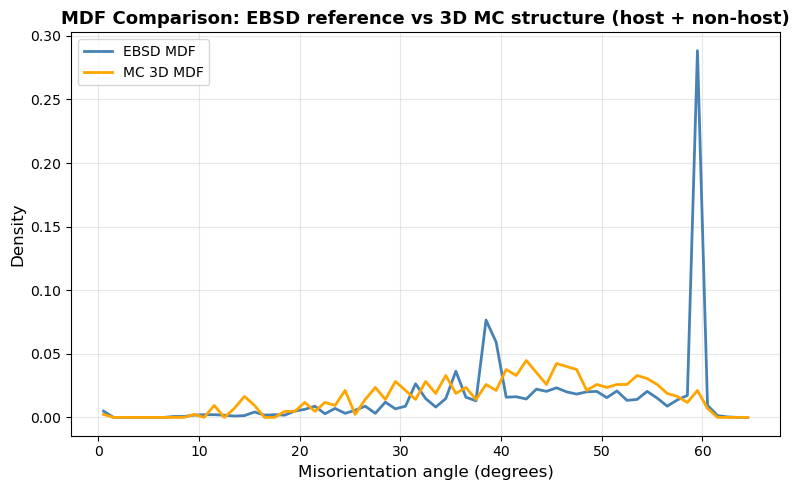

In [38]:
# Broadcast per-grain quaternions onto the full 3D voxel grid
quat_3d = np.zeros(gstslice.lgi.shape + (4,), dtype=np.float64)
for gid, q in all_grain_orientations.items():
    quat_3d[gstslice.lgi == gid] = q

# compute_mdf_from_quats expects neighbour values as arrays/lists, not sets
full_neigh_list = {gid: list(neighs) for gid, neighs in full_neigh.items()}

# Compute MDF for the 3D MC structure (dimension-agnostic function)
mc_mdf = compute_mdf_from_quats(gstslice.lgi, quat_3d, full_neigh_list, n_bins=65, angle_range=(0.0, 65.0))

print(f'MC 3D structure - mean misorientation: {mc_mdf["mean_angle"]:.2f} deg, n_pairs: {mc_mdf["n_pairs"]}')
if isinstance(mdf, dict):
    print(f'EBSD reference  - mean misorientation: {mdf["mean_angle"]:.2f} deg')
else:
    print(f'EBSD reference  - mean misorientation: {np.mean(mdf):.2f} deg')

# Overlay plot
fig, ax = plt.subplots(figsize=(8, 5))
if isinstance(mdf, dict):
    ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD MDF', color='steelblue', linewidth=2)
else:
    ax.hist(mdf, bins=65, range=(0, 65), density=True, alpha=0.5, label='EBSD MDF', color='steelblue')
ax.plot(mc_mdf['hist_bin_centers'], mc_mdf['hist_density'], label='MC 3D MDF', color='orange', linewidth=2)
ax.set_xlabel('Misorientation angle (degrees)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('MDF Comparison: EBSD reference vs 3D MC structure (host + non-host)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part G - Twin lamella introduction (morphology + crystallography)

### S38  EBSD twin thickness statistics

In [39]:
# Dimension-agnostic - operates purely on EBSD data, reusable as-is
twin_thickness = rg.compute_mc_twin_thickness(parent_info)

print(f'\nthick_um array size: {twin_thickness["thick_um"].size}')
print(f'abrupt_frac_ebsd: {twin_thickness["abrupt_frac_ebsd"]:.4f}')

  Twin thickness (minor_axis_length) and intercept statistics (EBSD):
  Metric                              Q1    Q2 (med)        Q3       IQR
  ──────────────────────────────────────────────────────────────────────
  Thickness (µm)                    2.16        3.42      5.99      3.83
  Intercept length (px)             1.00        1.00      8.00      7.00
  Abrupt twins: 599 / 901  (fraction = 0.669)

thick_um array size: 898
abrupt_frac_ebsd: 0.6693


### S39  Define 3D habit plane selection (generalised from the 2D XY-trace projection)

In [40]:
from upxo.xtalphy.crystal_orientation import compute_s3_habit_plane_3d

print('compute_s3_habit_plane_3d imported from upxo.xtalphy.crystal_orientation')

compute_s3_habit_plane_3d imported from upxo.xtalphy.crystal_orientation


### S40  Define 3D lamella voxel selection (reuses UPXO's Plane class)

In [41]:
from upxo.geoEntities.plane import Plane  # retained for direct use if needed
from upxo.pxtalops.twin3d import introduce_twin_lamella_3d

print('introduce_twin_lamella_3d imported from upxo.pxtalops.twin3d')

introduce_twin_lamella_3d imported from upxo.pxtalops.twin3d


### S41  Introduce primary Sigma3 twins into host grains

In [42]:
from upxo.xtalphy.crystal_orientation import _SIGMA3_Q, _quat_mul

rng_twin = np.random.default_rng(123)

lgi_twinned = gstslice.lgi.copy()
twin_role = {gid: 'non_host' for gid in non_host_grain_ids}
twin_parent_of = {}
all_quats_with_twins = dict(all_grain_orientations)

next_gid = int(lgi_twinned.max()) + 1
primary_twin_quats = {}
primary_twin_result = {}
n_abrupt = 0

abrupt_frac_ebsd = twin_thickness.get('abrupt_frac_ebsd', 0.0)
thick_um = twin_thickness['thick_um']
voxel_size = pxt.vox_size
TWIN_ORIENT_SCATTER_DEG = 1.5

# -- Meshing route controls minimum permissible lamella thickness ------------
MESHING_ROUTE = 'conformal'                   # 'conformal' or 'non_conformal'
MIN_TWIN_THICKNESS_VOXELS_CONFORMAL     = 2   # voxels: thinner causes non-manifold mesh
MIN_TWIN_THICKNESS_VOXELS_NON_CONFORMAL = 1   # voxels: single-voxel fine for non-conformal
_min_hw = (MIN_TWIN_THICKNESS_VOXELS_CONFORMAL if MESHING_ROUTE == 'conformal'
           else MIN_TWIN_THICKNESS_VOXELS_NON_CONFORMAL) / 2.0
n_clamped = 0

for gid in host_grain_ids:
    twin_role[gid] = 'host'
    q_par = all_grain_orientations[gid]
    coords = np.argwhere(lgi_twinned == gid)
    if coords.shape[0] == 0:
        primary_twin_result[gid] = None
        continue
    centroid = coords.mean(axis=0)

    normal = compute_s3_habit_plane_3d(q_par, rng_twin)
    hw = max(1.0, float(rng_twin.choice(thick_um)) / voxel_size / 2.0)

    if hw < _min_hw:
        hw = _min_hw
        n_clamped += 1

    is_abrupt = rng_twin.random() < abrupt_frac_ebsd

    twin_voxels = introduce_twin_lamella_3d(
        lgi_twinned, gid, centroid, normal, hw, next_gid,
        abrupt=is_abrupt, rng=rng_twin
    )

    if twin_voxels is not None and len(twin_voxels) > 0:
        q_twin = _quat_mul(_SIGMA3_Q, q_par)
        sc = rng_twin.normal(0.0, np.radians(TWIN_ORIENT_SCATTER_DEG))
        ax = rng_twin.standard_normal(3)
        ax = ax / np.linalg.norm(ax)
        pt = np.array([np.cos(sc / 2.0), *np.sin(sc / 2.0) * ax])
        q_twin = _quat_mul(pt, q_twin)
        q_twin = _positive_w(q_twin)

        primary_twin_quats[next_gid] = q_twin
        all_quats_with_twins[next_gid] = q_twin
        twin_role[next_gid] = 'primary_twin'
        twin_parent_of[next_gid] = gid
        primary_twin_result[gid] = next_gid
        if is_abrupt:
            n_abrupt += 1
        next_gid += 1
    else:
        primary_twin_result[gid] = None

n_primary_twins = len(primary_twin_quats)
print(f'Primary twins introduced: {n_primary_twins} / {len(host_grain_ids)} host grains')
if n_primary_twins > 0:
    print(f'Abrupt twins: {n_abrupt} ({100*n_abrupt/n_primary_twins:.1f}%)  (EBSD target: {100*abrupt_frac_ebsd:.1f}%)')
if n_clamped > 0:
    print(f'WARNING: {n_clamped} lamella half-widths clamped to {_min_hw:.1f} vox (route: {MESHING_ROUTE})')

Primary twins introduced: 31 / 31 host grains
Abrupt twins: 24 (77.4%)  (EBSD target: 66.9%)


### S42  Introduce secondary twins inside primary twin lamellae

In [43]:
sec_twin_frac = tvf.get('secondary_twin_frac', 0.0)
prim_twin_frac = tvf.get('primary_twin_frac', 1.0)
secondary_twin_quats = {}

if sec_twin_frac > 0 and prim_twin_frac > 0 and primary_twin_quats:
    sec_ratio = sec_twin_frac / max(prim_twin_frac, 1e-9)
    n_sec_host = max(1, round(len(primary_twin_quats) * sec_ratio))

    twin_voxel_counts = {tgid: int(np.sum(lgi_twinned == tgid)) for tgid in primary_twin_quats}
    sec_hosts = sorted(twin_voxel_counts, key=twin_voxel_counts.get, reverse=True)[:n_sec_host]

    for tgid in sec_hosts:
        q_sec_par = primary_twin_quats[tgid]
        coords = np.argwhere(lgi_twinned == tgid)
        if coords.shape[0] == 0:
            continue
        centroid = coords.mean(axis=0)
        normal = compute_s3_habit_plane_3d(q_sec_par, rng_twin)
        hw = max(1.0, float(rng_twin.choice(thick_um)) / voxel_size / 2.0)

        twin_voxels = introduce_twin_lamella_3d(
            lgi_twinned, tgid, centroid, normal, hw, next_gid,
            abrupt=False, rng=rng_twin
        )

        if twin_voxels is not None and len(twin_voxels) > 0:
            q_sec = _quat_mul(_SIGMA3_Q, q_sec_par)
            sc = rng_twin.normal(0.0, np.radians(TWIN_ORIENT_SCATTER_DEG))
            ax = rng_twin.standard_normal(3)
            ax = ax / np.linalg.norm(ax)
            pt = np.array([np.cos(sc / 2.0), *np.sin(sc / 2.0) * ax])
            q_sec = _quat_mul(pt, q_sec)
            q_sec = _positive_w(q_sec)

            secondary_twin_quats[next_gid] = q_sec
            all_quats_with_twins[next_gid] = q_sec
            twin_role[next_gid] = 'secondary_twin'
            twin_parent_of[next_gid] = tgid
            next_gid += 1

print(f'Secondary twin fraction target : {sec_twin_frac:.4f}')
print(f'Secondary twins introduced     : {len(secondary_twin_quats)}')

Secondary twin fraction target : 0.0014
Secondary twins introduced     : 1


### S43  Twin introduction summary statistics

In [44]:
print('Twin Introduction Summary')
print('=' * 60)
print(f'Original grains   : {gstslice.n}')
print(f'Host grains       : {len(host_grain_ids)}')
print(f'Primary twins     : {len(primary_twin_quats)}')
print(f'Secondary twins   : {len(secondary_twin_quats)}')
print(f'Non-host grains   : {len(non_host_grain_ids)}')

n_sub_regions = len(np.unique(lgi_twinned[lgi_twinned > 0]))
print(f'Total sub-regions : {n_sub_regions}')

all_twin_gids = list(primary_twin_quats.keys()) + list(secondary_twin_quats.keys())
total_twin_vox = sum(int(np.sum(lgi_twinned == g)) for g in all_twin_gids)
total_vox = int(np.sum(lgi_twinned > 0))
twin_vf_3d = total_twin_vox / total_vox if total_vox > 0 else 0.0

print(f'\nTwin volume fraction (3D MC) : {twin_vf_3d:.4f}')
print(f'Twin area fraction (EBSD)    : {tvf["overall_twin_frac"]:.4f}')

Twin Introduction Summary
Original grains   : 102
Host grains       : 31
Primary twins     : 31
Secondary twins   : 1
Non-host grains   : 71
Total sub-regions : 134

Twin volume fraction (3D MC) : 0.1245
Twin area fraction (EBSD)    : 0.0574


### S43b  Post-twin grain structure cleaning
Two-stage deterministic cleaning (no iterative defect-hopping):
- **Stage 1** - vertex spike removal (voxels with zero face-connected same-grain neighbours)
- **Stage 2** - lobe splitting via 6-connected component analysis (edge/corner-only contacts)

All grain features treated equally (host, non-host, primary twin, secondary twin).
Spike voxels are reassigned to the face-neighbour with the most face connections.
Disconnected lobes are relabelled as new grain IDs - never merged into neighbouring grains.

In [45]:
# -- Cleaning configuration -----------------------------------------------
UPSCALE_FALLBACK = False   # True: apply 2x spatial upscale (8x voxels) if cleaning cannot resolve all defects
SPLIT_JITTER_DEG = 0.0    # 0: both lobes keep same orientation; >0: minimum misorientation between lobes (deg)

In [46]:
from upxo.gsdataops.grid_ops import clean_voxel_spikes_3d

lgi_clean = lgi_twinned.copy()
lgi_clean, spike_count = clean_voxel_spikes_3d(lgi_clean)

print(f'Stage 1 complete: {spike_count} spike voxel(s) removed (one global pass)')

Stage 1 complete: 17 spike voxel(s) removed (one global pass)


In [47]:
from upxo.gsdataops.grid_ops import split_disconnected_lobes_3d

all_quats_with_twins_clean = dict(all_quats_with_twins)
twin_role_clean = dict(twin_role)
twin_parent_of_clean = dict(twin_parent_of)

all_gids_s2 = sorted(int(g) for g in __import__('numpy').unique(lgi_clean) if g > 0)
next_clean_gid = max(all_gids_s2) + 1

lgi_clean, all_quats_with_twins_clean, twin_role_clean, twin_parent_of_clean, split_events, next_clean_gid = \
    split_disconnected_lobes_3d(
        lgi_clean,
        all_quats_with_twins_clean,
        twin_role_clean,
        twin_parent_of_clean,
        next_clean_gid,
        rng_twin,
        split_jitter_deg=SPLIT_JITTER_DEG,
    )

n_splits = len(split_events)
print(f'Stage 2 complete: {n_splits} lobe(s) split into new grain IDs (one deterministic pass)')
if split_events:
    for new_gid, info in list(split_events.items())[:5]:
        j = f', jitter {info["jitter_applied_deg"]:.2f} deg' if info['jitter_applied_deg'] > 0 else ''
        print(f'  gid {info["parent_gid"]} -> new gid {new_gid} ({info["component_size_vox"]} vox{j})')
    if len(split_events) > 5:
        print(f'  ... ({len(split_events) - 5} more)')

Stage 2 complete: 12 lobe(s) split into new grain IDs (one deterministic pass)
  gid 3 -> new gid 135 (1143 vox)
  gid 5 -> new gid 136 (469 vox)
  gid 12 -> new gid 137 (341 vox)
  gid 31 -> new gid 138 (454 vox)
  gid 52 -> new gid 139 (2 vox)
  ... (7 more)


In [48]:
from scipy.ndimage import convolve as _convolve, label as _ndlabel

_face_kernel = np.array([
    [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
    [[0, 1, 0], [1, 0, 1], [0, 1, 0]],
    [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
], dtype=np.int32)

# Defect check and optional upscale fallback
remaining_spikes = 0
remaining_multi = 0

for gid in set(int(g) for g in np.unique(lgi_clean) if g > 0):
    mask = (lgi_clean == gid)
    fc = _convolve(mask.astype(np.int32), _face_kernel, mode='constant', cval=0)
    remaining_spikes += int(np.sum(mask & (fc == 0)))
    _, n_c = _ndlabel(mask.astype(np.uint8))
    if n_c > 1:
        remaining_multi += 1

print(f'Remaining spike voxels        : {remaining_spikes}')
print(f'Remaining multi-component grains: {remaining_multi}')

if (remaining_spikes > 0 or remaining_multi > 0) and UPSCALE_FALLBACK:
    print('\nUPSCALE FALLBACK: applying 2x spatial upscale (approx 8x voxel count in 3D).')
    print('WARNING: FEM element count will increase by approximately 8x.')
    lgi_clean = np.repeat(np.repeat(np.repeat(lgi_clean, 2, axis=0), 2, axis=1), 2, axis=2)
    print(f'Upscaled domain: {lgi_clean.shape}')
    print('Re-run Stage 1 and Stage 2 cells after this cell to clean the upscaled structure.')
elif remaining_spikes == 0 and remaining_multi == 0:
    print('\nPASS: Grain structure is topologically clean.')
else:
    print(f'\nWARNING: {remaining_spikes} spike voxel(s) and {remaining_multi} multi-component grain(s) remain.')
    print('Set UPSCALE_FALLBACK = True to attempt 2x spatial upscaling as a last resort.')

# Publish cleaned versions as canonical downstream references
# All cells downstream (S44 onwards) that reference lgi_twinned, twin_role,
# all_quats_with_twins will now use the cleaned versions automatically.
lgi_twinned          = lgi_clean
all_quats_with_twins = all_quats_with_twins_clean
twin_role            = twin_role_clean
twin_parent_of       = twin_parent_of_clean
print('\nPublished: lgi_twinned, all_quats_with_twins, twin_role, twin_parent_of  (cleaned versions)')

Remaining spike voxels        : 0
Remaining multi-component grains: 0

PASS: Grain structure is topologically clean.

Published: lgi_twinned, all_quats_with_twins, twin_role, twin_parent_of  (cleaned versions)


### S44  Visualise the 3D twinned structure (host / primary / secondary / non-host)

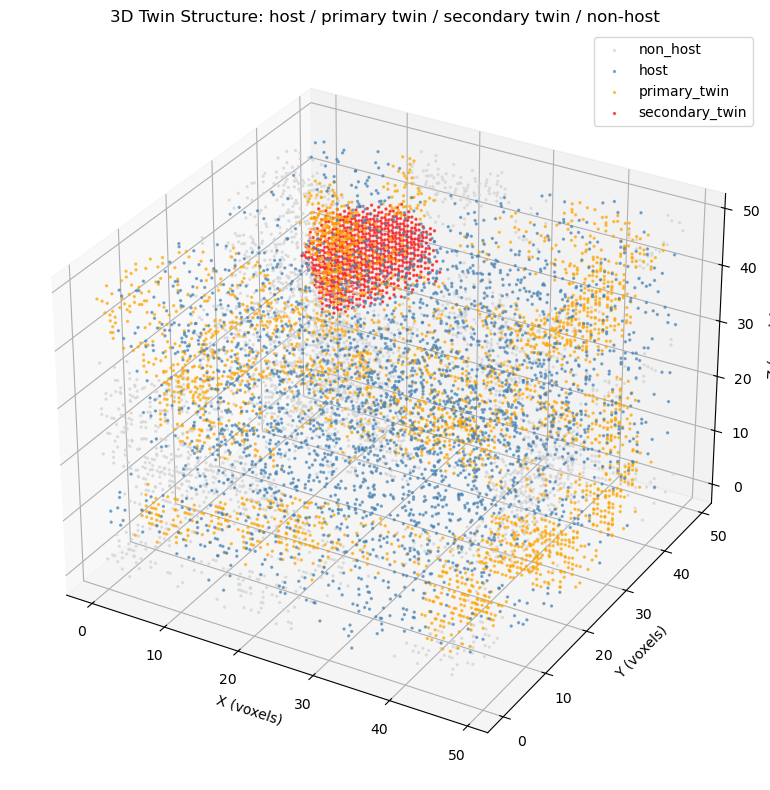

In [49]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

role_colors = {
    'non_host': 'lightgray',
    'host': 'steelblue',
    'primary_twin': 'orange',
    'secondary_twin': 'red',
}

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

max_points_per_role = 3000
for role, color in role_colors.items():
    gids_role = [g for g, r in twin_role.items() if r == role]
    if not gids_role:
        continue
    mask = np.isin(lgi_twinned, gids_role)
    coords = np.argwhere(mask)
    if coords.shape[0] > max_points_per_role:
        idx = np.random.choice(coords.shape[0], max_points_per_role, replace=False)
        coords = coords[idx]
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=2, c=color, label=role, alpha=0.6)

ax.set_xlabel('X (voxels)')
ax.set_ylabel('Y (voxels)')
ax.set_zlabel('Z (voxels)')
ax.set_title('3D Twin Structure: host / primary twin / secondary twin / non-host')
ax.legend()
plt.tight_layout()
plt.show()

### S45  MDF verification - 3D structure with twins vs EBSD reference

MC 3D structure (with twins) - mean misorientation: 41.93 deg, n_pairs: 688
EBSD reference - mean misorientation: 46.18 deg


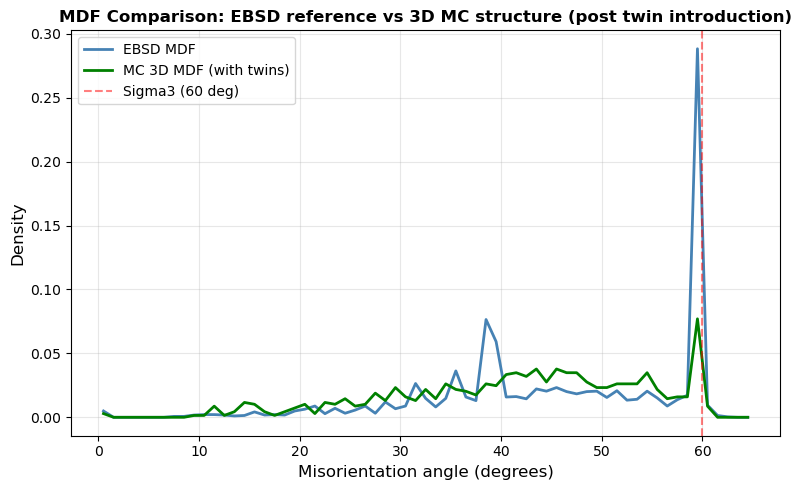

In [50]:
from upxo.gsdataops.gid_ops import find_neighs3d

# Neighbour graph of the twin-aware structure (does not require mutating gstslice)
neigh_twinned_raw = find_neighs3d(lgi_twinned, conn=6)
full_neigh_twinned = {int(g): [int(n) for n in neighs] for g, neighs in neigh_twinned_raw.items()}

# Broadcast quaternions (host + non-host + primary + secondary twins) onto the voxel grid
quat_3d_twinned = np.zeros(lgi_twinned.shape + (4,), dtype=np.float64)
for gid, q in all_quats_with_twins.items():
    quat_3d_twinned[lgi_twinned == gid] = q

mc_mdf_twinned = compute_mdf_from_quats(lgi_twinned, quat_3d_twinned, full_neigh_twinned,
                                         n_bins=65, angle_range=(0.0, 65.0))

print(f'MC 3D structure (with twins) - mean misorientation: '
      f'{mc_mdf_twinned["mean_angle"]:.2f} deg, n_pairs: {mc_mdf_twinned["n_pairs"]}')
if isinstance(mdf, dict):
    print(f'EBSD reference - mean misorientation: {mdf["mean_angle"]:.2f} deg')
else:
    print(f'EBSD reference - mean misorientation: {np.mean(mdf):.2f} deg')

fig, ax = plt.subplots(figsize=(8, 5))
if isinstance(mdf, dict):
    ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD MDF', color='steelblue', linewidth=2)
else:
    ax.hist(mdf, bins=65, range=(0, 65), density=True, alpha=0.5, label='EBSD MDF', color='steelblue')
ax.plot(mc_mdf_twinned['hist_bin_centers'], mc_mdf_twinned['hist_density'],
        label='MC 3D MDF (with twins)', color='green', linewidth=2)
ax.axvline(60.0, color='red', linestyle='--', alpha=0.5, label='Sigma3 (60 deg)')
ax.set_xlabel('Misorientation angle (degrees)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('MDF Comparison: EBSD reference vs 3D MC structure (post twin introduction)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part H - Post-twin 2D slice MDF re-validation (multi-axis)

### S46  2D slice extraction helper (lgi + quaternion pair)

In [51]:
from upxo.gsdataops.grid_ops import extract_2d_slice_pair

MDF_WASSERSTEIN_THRESHOLD_DEG = 5.0  # degrees - pass if slice MDF differs from EBSD by < this
print('extract_2d_slice_pair imported from upxo.gsdataops.grid_ops')
print('Reusing N_SLICES_X/Y/Z, TEST_ALONG_X/Y/Z, P_PERCENTAGE from Part D.')

extract_2d_slice_pair imported from upxo.gsdataops.grid_ops
Reusing N_SLICES_X/Y/Z, TEST_ALONG_X/Y/Z, P_PERCENTAGE from Part D.


### S47  Compute per-slice MDF and compare to EBSD reference (twinned structure)

In [52]:
ebsd_miso = mdf['miso_deg'] if isinstance(mdf, dict) else mdf

slice_results_h = {}
axes_config_h = [
    (0, N_SLICES_X, 'X', TEST_ALONG_X),
    (1, N_SLICES_Y, 'Y', TEST_ALONG_Y),
    (2, N_SLICES_Z, 'Z', TEST_ALONG_Z),
]

for axis, n_slices, axis_name, test_enabled in axes_config_h:
    if not test_enabled:
        continue

    axis_results = []
    domain_size = lgi_twinned.shape[axis]
    slice_indices = np.linspace(0, domain_size - 1, n_slices, dtype=int)

    print(f'\nProcessing {axis_name}-normal slices (n={n_slices}) - post-twin MDF check...')

    for slice_idx in slice_indices:
        lgi_2d, quat_2d = extract_2d_slice_pair(lgi_twinned, quat_3d_twinned, axis, slice_idx)

        if lgi_2d.max() <= 0:
            axis_results.append({'slice_idx': int(slice_idx), 'wasserstein': np.inf, 'passes': False})
            continue

        neigh_2d_raw = find_neighs2d(lgi_2d.astype(np.int32), conn=4)
        neigh_2d = {int(g): [int(n) for n in neighs] for g, neighs in neigh_2d_raw.items()}

        try:
            slice_mdf = compute_mdf_from_quats(lgi_2d, quat_2d, neigh_2d, n_bins=65, angle_range=(0.0, 65.0))
            w_dist = wasserstein_distance(ebsd_miso, slice_mdf['miso_deg']) if slice_mdf['miso_deg'].size > 0 else np.inf
        except Exception:
            w_dist = np.inf

        passes = w_dist < MDF_WASSERSTEIN_THRESHOLD_DEG
        axis_results.append({'slice_idx': int(slice_idx), 'wasserstein': w_dist, 'passes': passes})

    slice_results_h[axis_name] = axis_results
    n_pass = sum(1 for r in axis_results if r['passes'])
    pct_pass = 100.0 * n_pass / len(axis_results) if axis_results else 0
    print(f'  Result: {n_pass}/{len(axis_results)} slices pass ({pct_pass:.1f}%)')

print('\nPost-twin slice MDF analysis complete.')


Processing X-normal slices (n=10) - post-twin MDF check...
  Result: 9/10 slices pass (90.0%)

Processing Y-normal slices (n=10) - post-twin MDF check...
  Result: 10/10 slices pass (100.0%)

Processing Z-normal slices (n=10) - post-twin MDF check...
  Result: 9/10 slices pass (90.0%)

Post-twin slice MDF analysis complete.


### S48  Aggregate per-axis acceptance (post-twin)

In [53]:
axis_acceptance_h = {}

print('\nPost-Twin Per-Axis MDF Representativeness Summary')
print('=' * 60)

for axis_name, results in slice_results_h.items():
    n_pass = sum(1 for r in results if r['passes'])
    n_total = len(results)
    pct_pass = 100.0 * n_pass / n_total if n_total > 0 else 0
    accepted = pct_pass >= P_PERCENTAGE
    axis_acceptance_h[axis_name] = {
        'n_pass': n_pass, 'n_total': n_total, 'pct_pass': pct_pass, 'accepted': accepted
    }
    status = 'ACCEPTED' if accepted else 'REJECTED'
    print(f'{axis_name}-axis: {n_pass}/{n_total} slices pass ({pct_pass:.1f}%) [{status}]')

overall_accepted_h = all(info['accepted'] for info in axis_acceptance_h.values())

print('\n' + '=' * 60)
if overall_accepted_h:
    print('OVERALL POST-TWIN MDF ACCEPTANCE: YES')
else:
    rejected_axes = [ax for ax, info in axis_acceptance_h.items() if not info['accepted']]
    print(f'OVERALL POST-TWIN MDF ACCEPTANCE: NO  (rejected axes: {rejected_axes})')
print('=' * 60)


Post-Twin Per-Axis MDF Representativeness Summary
X-axis: 9/10 slices pass (90.0%) [ACCEPTED]
Y-axis: 10/10 slices pass (100.0%) [ACCEPTED]
Z-axis: 9/10 slices pass (90.0%) [ACCEPTED]

OVERALL POST-TWIN MDF ACCEPTANCE: YES


### S49  Visualise post-twin per-axis pass rates

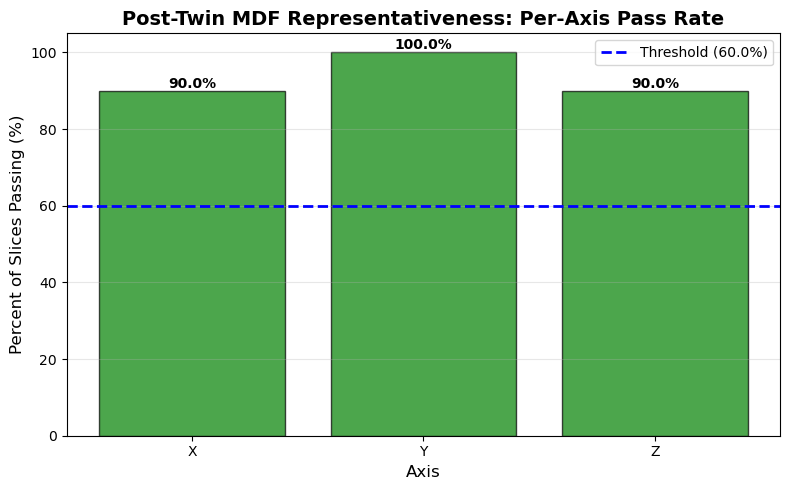


Part H complete.


In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
axes_names_h = list(axis_acceptance_h.keys())
pct_passes_h = [axis_acceptance_h[ax_]['pct_pass'] for ax_ in axes_names_h]
colors_h = ['green' if axis_acceptance_h[ax_]['accepted'] else 'red' for ax_ in axes_names_h]

bars = ax.bar(axes_names_h, pct_passes_h, color=colors_h, alpha=0.7, edgecolor='black')
ax.axhline(y=P_PERCENTAGE, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({P_PERCENTAGE}%)')
ax.set_ylabel('Percent of Slices Passing (%)', fontsize=12)
ax.set_xlabel('Axis', fontsize=12)
ax.set_title('Post-Twin MDF Representativeness: Per-Axis Pass Rate', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, pct in zip(bars, pct_passes_h):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nPart H complete.')

## Part I - Visualisation and export

### S50  3D PyVista visualisation (per-role opacity)

In [55]:
import pyvista as pv

role_opacity = {'non_host': 0.25, 'host': 0.8, 'primary_twin': 0.6, 'secondary_twin': 0.6}
role_cmap = {'non_host': 'gray', 'host': 'Blues', 'primary_twin': 'Oranges', 'secondary_twin': 'Reds'}

pvp = pv.Plotter()
for role, alpha in role_opacity.items():
    gids_role = [g for g, r in twin_role.items() if r == role]
    if not gids_role:
        continue
    masked = np.where(np.isin(lgi_twinned, gids_role), lgi_twinned, 0)

    grid = pv.ImageData()
    grid.dimensions = np.array(masked.shape) + 1
    grid.origin = (0, 0, 0)
    grid.spacing = (1, 1, 1)
    grid.cell_data['lgi'] = masked.flatten(order='F')
    grid_thresh = grid.threshold(0.5, scalars='lgi')

    pvp.add_mesh(grid_thresh, opacity=alpha, cmap=role_cmap[role], show_edges=False, label=role)

pvp.add_legend()
pvp.show()

Widget(value='<iframe src="http://localhost:53671/index.html?ui=P_0x1b5c7cf2660_0&reconnect=auto" class="pyvis…

### S51  IPF-coloured 2D slice (user-specified axis + position)

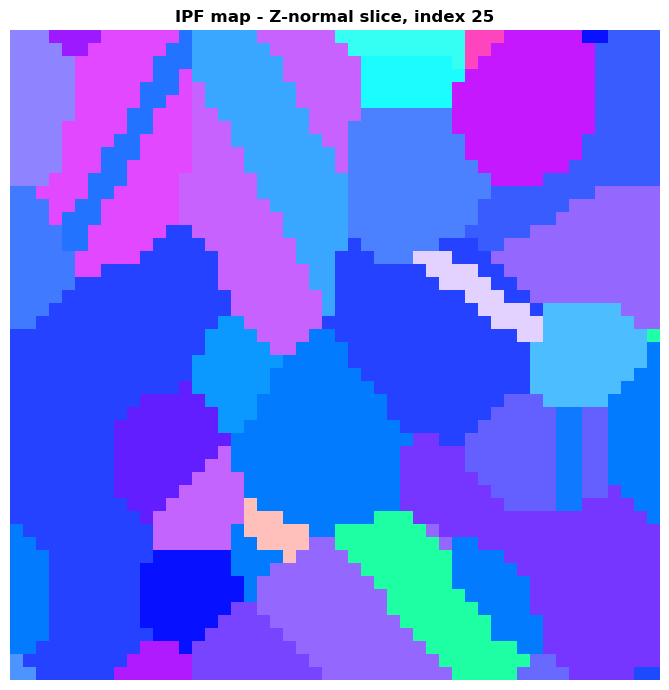

In [56]:
from upxo.viz import ebsdviz

VIZ_AXIS = 2              # 0 = X, 1 = Y, 2 = Z
VIZ_SLICE_INDEX = lgi_twinned.shape[VIZ_AXIS] // 2   # mid-slice by default

if VIZ_AXIS == 0:
    lgi_2d_viz = lgi_twinned[VIZ_SLICE_INDEX, :, :]
elif VIZ_AXIS == 1:
    lgi_2d_viz = lgi_twinned[:, VIZ_SLICE_INDEX, :]
else:
    lgi_2d_viz = lgi_twinned[:, :, VIZ_SLICE_INDEX]

rgb_slice = ebsdviz.build_ipf_rgb(lgi_2d_viz.astype(np.int64), all_quats_with_twins, sample_direction=(0, 0, 1))

axis_label = ['X', 'Y', 'Z'][VIZ_AXIS]
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(rgb_slice)
ax.set_title(f'IPF map - {axis_label}-normal slice, index {VIZ_SLICE_INDEX}', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### S52  Export final structure to disk

In [57]:
import os
import pickle

OUT_DIR_3D = r'C:\Development\UPXO\upxo_library\src\upxo\_written_data\Twinned3D'
os.makedirs(OUT_DIR_3D, exist_ok=True)

np.save(os.path.join(OUT_DIR_3D, '3d_grain_structure_twinned.npy'), lgi_twinned)

with open(os.path.join(OUT_DIR_3D, 'orientations_all.pkl'), 'wb') as f:
    pickle.dump(all_quats_with_twins, f)

with open(os.path.join(OUT_DIR_3D, 'twin_role.pkl'), 'wb') as f:
    pickle.dump(twin_role, f)

with open(os.path.join(OUT_DIR_3D, 'twin_parent_of.pkl'), 'wb') as f:
    pickle.dump(twin_parent_of, f)

print(f'Exported to: {OUT_DIR_3D}')
print('  3d_grain_structure_twinned.npy  - voxel label array')
print('  orientations_all.pkl            - {gid: quaternion} for every sub-region')
print('  twin_role.pkl                   - {gid: role string}')
print('  twin_parent_of.pkl              - {twin_gid: parent_gid} provenance')

Exported to: C:\Development\UPXO\upxo_library\src\upxo\_written_data\Twinned3D
  3d_grain_structure_twinned.npy  - voxel label array
  orientations_all.pkl            - {gid: quaternion} for every sub-region
  twin_role.pkl                   - {gid: role string}
  twin_parent_of.pkl              - {twin_gid: parent_gid} provenance


### S53  Final summary report

In [58]:
report_lines = []
report_lines.append('3D Representative Twinned Grain Structure - Summary Report')
report_lines.append('=' * 65)
report_lines.append(f'MC time slice : {tslice_for_detailed_analysis}')
report_lines.append(f'Domain        : {lgi_twinned.shape[0]} x {lgi_twinned.shape[1]} x {lgi_twinned.shape[2]} voxels')
report_lines.append(f'Voxel size    : {pxt.vox_size} um')
report_lines.append('')
report_lines.append('Pre-twin morphological representativeness (Part D):')
report_lines.append(f'  Overall acceptance : {"PASS" if overall_accepted else "FAIL"}')
for axis_name, info in axis_acceptance.items():
    report_lines.append(f'    {axis_name}-axis : {info["pct_pass"]:.1f}%  (threshold {P_PERCENTAGE}%)')
report_lines.append('')
report_lines.append('Twin host allocation (Part E):')
report_lines.append(f'  Target hosting fraction   : {target_hosting_fraction:.4f}')
report_lines.append(f'  Achieved hosting fraction : {actual_fraction:.4f}')
report_lines.append(f'  Host grains               : {actual_n_hosts}')
report_lines.append('')
report_lines.append('Orientation assignment (Part F):')
report_lines.append(f'  Conflict-free check         : {"PASS" if conflicts == 0 else "FAIL"}  ({conflicts} conflicts)')
report_lines.append(f'  Pre-twin 3D MDF mean misori : {mc_mdf["mean_angle"]:.2f} deg')
ebsd_mean_angle = mdf['mean_angle'] if isinstance(mdf, dict) else float(np.mean(mdf))
report_lines.append(f'  EBSD MDF mean misori        : {ebsd_mean_angle:.2f} deg')
report_lines.append('')
report_lines.append('Twin introduction (Part G):')
report_lines.append(f'  Primary twins             : {len(primary_twin_quats)}')
report_lines.append(f'  Secondary twins           : {len(secondary_twin_quats)}')
report_lines.append(f'  3D twin volume fraction   : {twin_vf_3d:.4f}')
report_lines.append(f'  EBSD twin area fraction   : {tvf["overall_twin_frac"]:.4f}')
report_lines.append(f'  Post-twin 3D MDF mean misori : {mc_mdf_twinned["mean_angle"]:.2f} deg')
report_lines.append('')
report_lines.append('Post-twin 2D slice MDF re-validation (Part H):')
report_lines.append(f'  Overall acceptance : {"PASS" if overall_accepted_h else "FAIL"}')
for axis_name, info in axis_acceptance_h.items():
    report_lines.append(f'    {axis_name}-axis : {info["pct_pass"]:.1f}%  (threshold {P_PERCENTAGE}%)')

report_text = '\n'.join(report_lines)
print(report_text)

report_path = os.path.join(OUT_DIR_3D, 'representativeness_report.txt')
with open(report_path, 'w') as f:
    f.write(report_text)

print(f'\nReport saved to: {report_path}')
print('\nPipeline complete: Parts A-I.')

3D Representative Twinned Grain Structure - Summary Report
MC time slice : 99
Domain        : 50 x 50 x 50 voxels
Voxel size    : 1.0 um

Pre-twin morphological representativeness (Part D):
  Overall acceptance : PASS
    X-axis : 100.0%  (threshold 60.0%)
    Y-axis : 90.0%  (threshold 60.0%)
    Z-axis : 100.0%  (threshold 60.0%)

Twin host allocation (Part E):
  Target hosting fraction   : 0.8408
  Achieved hosting fraction : 0.8485
  Host grains               : 31

Orientation assignment (Part F):
  Conflict-free check         : PASS  (0 conflicts)
  Pre-twin 3D MDF mean misori : 40.61 deg
  EBSD MDF mean misori        : 46.18 deg

Twin introduction (Part G):
  Primary twins             : 31
  Secondary twins           : 1
  3D twin volume fraction   : 0.1245
  EBSD twin area fraction   : 0.0574
  Post-twin 3D MDF mean misori : 41.93 deg

Post-twin 2D slice MDF re-validation (Part H):
  Overall acceptance : PASS
    X-axis : 90.0%  (threshold 60.0%)
    Y-axis : 100.0%  (threshold 

In [59]:
# Split events report (Part G cleaning)
import os as _os
if split_events:
    print(f'Split events: {len(split_events)} lobe(s) relabelled as new grain IDs')
    print('(Topologically disconnected regions within a grain, relabelled but not merged into neighbours)')
    for new_gid, info in split_events.items():
        j = f', jitter {info["jitter_applied_deg"]:.2f} deg' if info['jitter_applied_deg'] > 0 else ' (same orientation)'
        print(f'  {new_gid} <- parent {info["parent_gid"]} | {info["component_size_vox"]} vox{j}')
    _sp = _os.path.join(OUT_DIR_3D, 'split_events_report.txt')
    with open(_sp, 'w') as _f:
        _f.write(f'Split events: {len(split_events)}\n')
        for new_gid, info in split_events.items():
            j = f'{info["jitter_applied_deg"]:.2f}' if info['jitter_applied_deg'] > 0 else '0.00'
            _f.write(f'{new_gid} <- parent {info["parent_gid"]} | {info["component_size_vox"]} vox | jitter {j} deg\n')
    print(f'Split events report saved to: {_sp}')
else:
    print('No split events - grain structure was topologically clean after Stage 1 and Stage 2.')

Split events: 12 lobe(s) relabelled as new grain IDs
(Topologically disconnected regions within a grain, relabelled but not merged into neighbours)
  135 <- parent 3 | 1143 vox (same orientation)
  136 <- parent 5 | 469 vox (same orientation)
  137 <- parent 12 | 341 vox (same orientation)
  138 <- parent 31 | 454 vox (same orientation)
  139 <- parent 52 | 2 vox (same orientation)
  140 <- parent 53 | 322 vox (same orientation)
  141 <- parent 76 | 856 vox (same orientation)
  142 <- parent 90 | 1203 vox (same orientation)
  143 <- parent 99 | 207 vox (same orientation)
  144 <- parent 112 | 406 vox (same orientation)
  145 <- parent 133 | 4 vox (same orientation)
  146 <- parent 133 | 2 vox (same orientation)
Split events report saved to: C:\Development\UPXO\upxo_library\src\upxo\_written_data\Twinned3D\split_events_report.txt
